# Threshold tools

This notebook demonstrates how to use `climakitae` to evaluate threshold exceedences for extreme weather events in downscaled climate model simulations. 

`climakitae` uses the Annual Maxima Series (AMS) method, as opposed to the alternative Peaks-Over-Threshold (POT) method, for extreme value analysis. In the AMS method, the maximum (or minimum) variable value is obtained for each year. A statistical distribution is fitted to the values and can then be used to obtain return probabilities, values, or periods. Users will have to option to choose their distribution along with other customizations.

**Terms used in this notebook**:
- __Return probabilities__: The probability of a threshold being exceeded within a given period of time. 
    - For example, the maximum temperature at a location has a 10% chance of exceeding 105°F in any year.
- __Return values__: A threshold expected to be exceeded at least once in a set period of time. 
    - A maximum temperature value that has a 10% annual return probability is the 10-year maximum temperature return value.
- __Return periods__: The frequency with which a threshold is expected to be exceeded at least once.
    - If the return probability of exceeding 150 mm of precipitation is 10%, the return period of that event is 10 years.

**Intended Application**: As a user, I want to learn how to:
- **<span style="color:#FF0000">Generate return probabilities, return values, and return periods for climate simulations with climakitae.</span>**
- **<span style="color:#FF0000">Visualize the spatial distribution of return value results across a region.</span>**

**Runtime**: With the default settings, this notebook takes approximately **5 minutes** to run from start to finish. Modifications to selections may increase the runtime.

**References**: The techniques in this notebook come from applications of extreme value theory to climate data. For further reading on this topic, see [Cooley 2009](https://link.springer.com/article/10.1007/s10584-009-9627-x).


### 1-in-X options

The following arguments can be passed to `one_in_x` in the `metric_calc` processor:

| Argument | Options | Required? | Notes |
|---|---|---|---|
| `return_periods` | List of ints | Required (or `return_values`) | Return periods in years, e.g. `[10, 25, 50]` |
| `return_values` | List of floats | Required (or `return_periods`) | Threshold values, e.g. `[105]` |
| `extremes_type` | `"max"`, `"min"` | Optional | Default: `"max"` |
| `distribution` | `"gev"`, `"genpareto"`, `"gumbel"`, `"weibull"`, `"pearson3"`, `"gamma"` | Optional | Default: `"gev"` |
| `event_duration` | `(int, "day")` | Optional | Window for sub-daily events |
| `grouped_duration` | `(int, "day")` | Optional | Consecutive-day event window for multi-day extremes |
| `block_size` | int (years) | Optional | Default: 1 |
| `goodness_of_fit_test` | bool | Optional | Default: `True`; runs KS test, returns p-values |

In [19]:
import climakitae as ck
import matplotlib.pyplot as plt

## 1. Return values: precipitation at a single location

In this example, we calculate 1-in-X return values for daily precipitation at a single station (KSAC) across two warming levels.

In [5]:
# Initialize the interface
cd = ck.ClimateData(verbosity=0)

one_in_x_data = (
    cd.catalog("cadcat")
    .activity_id("WRF")
    .institution_id("UCLA")
    .table_id("day")
    .grid_label("d02")
    .variable("prec")
    .processes(
        {
            "warming_level": {"warming_levels": [0.8, 2.0]},
            "convert_units": "inches/d",
            "clip": "KSAC",
            "metric_calc": {
                "one_in_x": {
                    "return_periods": [10, 25, 50],
                    "extremes_type": "max",
                }
            },
        }
    )
    .get()
)

2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - Initializing ClimateData interface
2026-04-07 18:12:31 - climakitae.new_core.dataset_factory - INFO - DatasetFactory initialized with 3 validators and 12 processors
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - ClimateData initialization successful
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - ✅ Ready to query!
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - Catalog set to: cadcat
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - Activity ID set to: WRF
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - Institution ID set to: UCLA
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - Table ID set to: day
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - Grid label set to: d02
2026-04-07 18:12:31 - climakitae.new_core.user_interface - INFO - Variable set to: prec
2026-04-07 18:12:31 - climakitae.new_core.us


Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d02.r1i1p1f1 at 0.8C. 
Skipping this warming level.
  warnings.warn(



2026-04-07 18:12:41 - climakitae.new_core.processors.warming_level - WARNING - 

Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d02.r1i1p1f1 at 0.8C. 
Skipping this warming level.
2026-04-07 18:12:42 - climakitae.new_core.processors.concatenate - INFO - Concatenated datasets along 'sim' dimension.
2026-04-07 18:12:45 - climakitae.new_core.processors.clip - INFO - Found valid data at closest gridcell: lat=38.5435, lon=-121.4918
2026-04-07 18:12:45 - climakitae.new_core.processors.metric_calc - INFO - Detected Dask array - using optimized chunked processing...
2026-04-07 18:12:45 - climakitae.new_core.processors.metric_calc - INFO - Total size of data array: 0.44 MB
2026-04-07 18:12:45 - climakitae.new_core.processors.metric_calc - INFO - Small array detected - loading into memory...
2026-04-07 18:12:51 - climakitae.new_core.processors.metric_calc - INFO - Calculating 1-in-[10 25 50] year return values using gev distribution...
2026-04-07 18:12:51 - climakitae.new_core.pr

In [17]:
# Removing `EC-Earth3-Veg` because it's an incomplete WL slice
sims = [s.item() for s in one_in_x_data.sim if "EC-Earth3-Veg" not in s.item()]
one_in_x_data = one_in_x_data.sel(sim=sims)

The p-value from the Kolmogorov-Smirnov (KS) test measures how well the chosen distribution fits the annual maxima series. A p-value above 0.05 indicates an acceptable fit at the 95% confidence level. Low p-values suggest the distribution may not be appropriate for the data-- try a different `distribution` option in that case.

In [7]:
# Examining p-values across simulation, warming_level, and one_in_x combinations
one_in_x_data.to_dataframe()[["p_values"]]

p_values
sim                                            warming_level one_in_x          
WRF_UCLA_TaiESM1_ssp370_day_d02_r1i1p1f1       0.8           10        0.887097
                                                             25        0.887097
                                                             50        0.887097
                                               2.0           10        0.973609
                                                             25        0.973609
                                                             50        0.973609
WRF_UCLA_MPI-ESM1-2-HR_ssp370_day_d02_r3i1p1f1 0.8           10        0.749863
                                                             25        0.749863
                                                             50        0.749863
                                               2.0           10        0.713247
                                                             25        0.713247
                                                             50        0.713247
WRF_UCLA_MIROC6_ssp370_day_d02_r1i1p1f1        0.8           10        0.708813
                                                             25        0.708813
                                                             50        0.708813
                                               2.0           10        0.990023
                                                             25        0.990023
                                                             50        0.990023
WRF_UCLA_EC-Earth3_ssp370_day_d02_r1i1p1f1     0.8           10        0.965006
                                                             25        0.965006
                                                             50        0.965006
                                               2.0           10        0.958378
                                                             25        0.958378
                                                             50        0.958378

In [8]:
# Looking at the `return_values` now that we've confirmed the p-values are all reasonable
one_in_x_data.to_dataframe()[["return_values"]].groupby(
    ["warming_level", "one_in_x"]
).mean()

return_values
warming_level one_in_x               
0.8           10             3.590997
              25             4.409765
              50             5.076995
2.0           10             3.556855
              25             4.310320
              50             4.922223

## 2. Return periods: temperature over a region

Here, we find the return period for a specific temperature threshold (105°F for a 3-day heat wave) across San Bernardino County using a future time period.  We then plot the results as a spatial map.

In [9]:
# Initialize the interface
cd = ck.ClimateData(verbosity=0)

one_in_x_temp = (
    cd.catalog("cadcat")
    .activity_id("WRF")
    .experiment_id(["historical", "ssp370"])
    .institution_id("UCLA")
    .table_id("day")
    .grid_label("d02")
    .variable("t2max")
    .processes(
        {
            "time_slice": (2040, 2060),
            "convert_units": "degF",
            "clip": "San Bernardino County",
            "metric_calc": {
                "one_in_x": {
                    "return_values": [105],
                    "block_size": 1,
                    "extremes_type": "max",
                    "event_duration": (1, "day"),
                    "grouped_duration": (3, "day"),
                }
            },
        }
    )
    .get()
)

2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - Initializing ClimateData interface
2026-04-07 18:12:53 - climakitae.new_core.dataset_factory - INFO - DatasetFactory initialized with 3 validators and 12 processors
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - ClimateData initialization successful
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - ✅ Ready to query!
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - Catalog set to: cadcat
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - Activity ID set to: WRF
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - Experiment ID(s) set to: ['historical', 'ssp370']
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - Institution ID set to: UCLA
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - Table ID set to: day
2026-04-07 18:12:53 - climakitae.new_core.user_interface - INFO - Grid label set to: d02
2026-04-07 18:12

  return_periods = 1.0 / return_prob



2026-04-07 18:16:05 - climakitae.new_core.processors.metric_calc - INFO - Creating result dataset...
2026-04-07 18:16:05 - climakitae.new_core.processors.metric_calc - INFO - Batch 1/1 complete (183.4s total)
2026-04-07 18:16:06 - climakitae.new_core.processors.metric_calc - INFO - All batches complete. Combining 1 batch results...
2026-04-07 18:16:06 - climakitae.new_core.processors.metric_calc - INFO - Final result shape: {'sim': 5, 'y': 36, 'x': 35, 'one_in_x': 1}
2026-04-07 18:16:06 - climakitae.new_core.processors.update_attributes - INFO - UpdateAttributes applied to result; added 8 attributes
2026-04-07 18:16:06 - climakitae.new_core.dataset - INFO - All processing steps completed successfully
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - ✅ Data retrieval successful!


<br>

**Larger return periods indicate less frequent events. Areas with low return periods are more susceptible to 3-day heat waves at 105°F.**

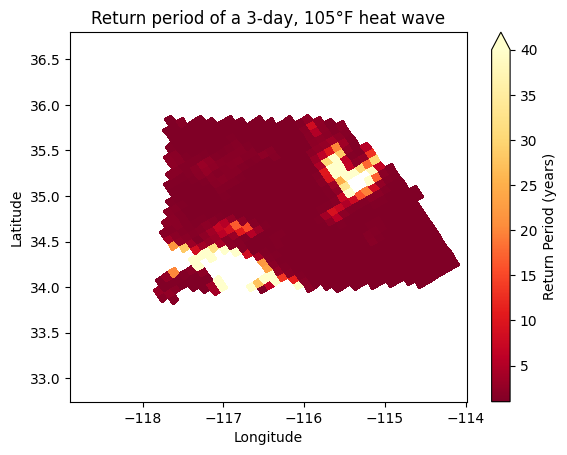

In [10]:
fig, ax = plt.subplots()
one_in_x_temp["return_periods"].median("sim").sel(one_in_x=105).plot(
    vmax=40, cmap="YlOrRd_r", x="lon", y="lat",
    ax=ax,
    cbar_kwargs={"label": "Return Period (years)"},
)
ax.set_title("Return period of a 3-day, 105°F heat wave")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 3. Return period for a given threshold

Another question we can answer using `climakitae`, is **how does the return period of a specific event change across warming levels?** 

Here, we take the median 10-year precipitation return value at WL 0.8 from Section 1, and find its return period at WL 2.0.

In [18]:
# Extract the median 10-year return value at WL 0.8 as our threshold
threshold_val = float(
    one_in_x_data.to_dataframe()["return_values"]
    .xs(0.8, level="warming_level")
    .xs(10, level="one_in_x")
    .median()
)
print(f"10-year return value at WL 0.8: {threshold_val:.2f} inches/day")

10-year return value at WL 0.8: 3.56 inches/day


In [12]:
# Find the return period for that threshold at both warming levels
cd = ck.ClimateData(verbosity=0)

return_period_data = (
    cd.catalog("cadcat")
    .activity_id("WRF")
    .institution_id("UCLA")
    .table_id("day")
    .grid_label("d02")
    .variable("prec")
    .processes(
        {
            "warming_level": {"warming_levels": [0.8, 2.0]},
            "convert_units": "inches/d",
            "clip": "KSAC",
            "metric_calc": {
                "one_in_x": {
                    "return_values": [threshold_val],
                    "extremes_type": "max",
                }
            },
        }
    )
    .get()
)

# Dropping simulations with incomplete WL data
sims = [s.item() for s in return_period_data.sim if "EC-Earth3-Veg" not in s.item()]
return_period_data = return_period_data.sel(sim=sims)

2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - Initializing ClimateData interface
2026-04-07 18:16:06 - climakitae.new_core.dataset_factory - INFO - DatasetFactory initialized with 3 validators and 12 processors
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - ClimateData initialization successful
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - ✅ Ready to query!
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - Catalog set to: cadcat
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - Activity ID set to: WRF
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - Institution ID set to: UCLA
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - Table ID set to: day
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - Grid label set to: d02
2026-04-07 18:16:06 - climakitae.new_core.user_interface - INFO - Variable set to: prec
2026-04-07 18:16:06 - climakitae.new_core.us


Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d02.r1i1p1f1 at 0.8C. 
Skipping this warming level.
  warnings.warn(



2026-04-07 18:16:15 - climakitae.new_core.processors.warming_level - WARNING - 

Incomplete warming level for WRF.UCLA.EC-Earth3-Veg.ssp370.day.d02.r1i1p1f1 at 0.8C. 
Skipping this warming level.
2026-04-07 18:16:16 - climakitae.new_core.processors.concatenate - INFO - Concatenated datasets along 'sim' dimension.
2026-04-07 18:16:19 - climakitae.new_core.processors.clip - INFO - Found valid data at closest gridcell: lat=38.5435, lon=-121.4918
2026-04-07 18:16:19 - climakitae.new_core.processors.metric_calc - INFO - Detected Dask array - using optimized chunked processing...
2026-04-07 18:16:19 - climakitae.new_core.processors.metric_calc - INFO - Total size of data array: 0.44 MB
2026-04-07 18:16:19 - climakitae.new_core.processors.metric_calc - INFO - Small array detected - loading into memory...
2026-04-07 18:16:25 - climakitae.new_core.processors.metric_calc - INFO - Calculating return periods for return values [3.56316] using gev distribution...
2026-04-07 18:16:25 - climakitae.new

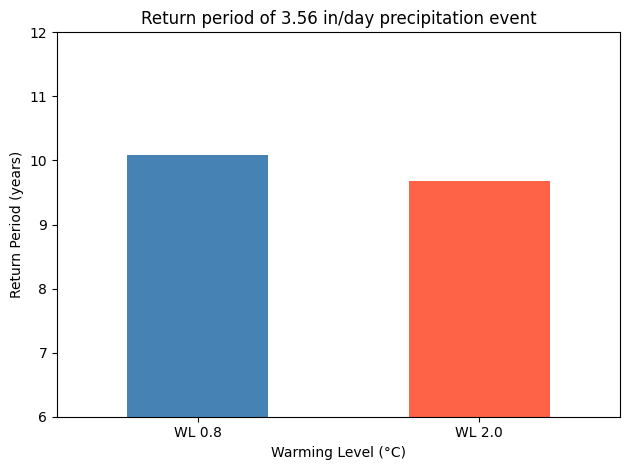

In [13]:
# Plotting the return period for the same return value across WL 0.8 and 2.0
rp_summary = (
    return_period_data.to_dataframe()[["return_periods"]]
    .groupby("warming_level")
    .median()
)

fig, ax = plt.subplots()
rp_summary["return_periods"].plot(kind="bar", ax=ax, color=["steelblue", "tomato"])
ax.set_xlabel("Warming Level (°C)")
ax.set_ylabel("Return Period (years)")
ax.set_title(f"Return period of {threshold_val:.2f} in/day precipitation event")
ax.set_xticklabels([f"WL {wl}" for wl in rp_summary.index], rotation=0)
ax.set_ylim(6, 12)
plt.tight_layout()
plt.show()

**At WL 0.8, this event is by construction a 10-year return event. A shorter return period at WL 2.0 means the same precipitation amount is expected more frequently, which indicates the intensification of extreme precipitation at a higher warming level.**

## 4. Other notebooks that use threshold analyses
Now that you've seen how the different `1-in-X` calculations can be performed using `climakitae`, here's a few other notebooks that we support that use similar functionality for various other use cases:

- **[Vulnerability Assessment](../collaborative/IOU/vulnerability_assessment/vulnerability_assessment.ipynb)**: Pre-built metric tables for IOU utility planning. Uses `cava_data()` to generate standardized 1-in-X outputs, percentiles,  across multiple variables.

- **[Event Finder](../work-in-progress/event_finder.ipynb)**: Identifies specific historical or projected extreme events that match a given threshold or 1-in-X event, useful for understanding specific behavior.

- **[Custom 1-in-X](../work-in-progress/custom_1_in_x.ipynb)**: Calculates 1-in-X return values for customized metrics and/or variables.

- **[1-in-X into 8760](../collaborative/IOU/8760/one_in_x_in_8760.ipynb)**: Generates an 8760 timeseries, and inserts 1-in-X events into them, to capture what yearly behavior would look like with an extreme event.